# Aula 3 — Detecção e Tratamento de Duplicatas e Valores Ausentes

**Disciplina:** Validação de Dados em ML e Bibliotecas de Qualidade  
**Programa:** POSTECH – FIAP

---

## Objetivos

Ao final deste notebook você será capaz de:

1. Criar um dataset sintético contendo de forma proposital duplicatas exatas e near-duplicates
2. Detectar e remover **duplicatas exatas** com hashing SHA-256
3. Detectar e remover **near-duplicates** em campos categóricos com MinHash + LSH
4. Identificar **data leakage** por duplicatas entre treino e teste
5. Visualizar padrões de dados ausentes com `missingno` na base de treino
6. Comparar e validar estratégias de imputação evitando vazamento de dados

**Dataset:** prontuários médicos sintéticos (criado neste notebook)  
**Bibliotecas:** `pandas`, `numpy`, `scikit-learn`, `missingno`, `datasketch`, `matplotlib`

## Setup

In [1]:
import hashlib

import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
from datasketch import MinHash, MinHashLSH
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

np.random.seed(42)
pd.set_option('display.float_format', '{:.1f}'.format)
plt.rcParams['figure.dpi'] = 110

---
## Passo 1 — Geração do Dataset Sintético (com Duplicatas)

Nesta etapa, vamos construir o nosso dataset inicial já contendo os problemas que queremos tratar:
1. Registros originais
2. Duplicatas exatas (cópias idênticas do mesmo registro)
3. Near-duplicates (registros com variações como erros de digitação e acentuação)

In [2]:
# Dataset Base (15 pacientes originais)
df_base = pd.DataFrame({
    'paciente_id': range(1, 16),
    'nome':        ['Ana Lima',      'Bruno Rocha',     'Carla Dias',
                    'Daniel Souza',  'Elena Ferreira',  'Fábio Costa',
                    'Gisele Nunes',  'Henrique Alves',  'Iara Martins',
                    'João Peixoto',  'Karen Silva',     'Lucas Barbosa',
                    'Mariana Gomes', 'Nelson Teixeira', 'Olívia Ramos'],
    'cidade':      ['São Paulo',       'Rio de Janeiro', 'Belo Horizonte',
                    'Salvador',        'Fortaleza',      'Curitiba',
                    'Manaus',          'Recife',         'Porto Alegre',
                    'Goiânia',         'Belém',          'São Paulo',
                    'Rio de Janeiro',  'Curitiba',       'Brasília'],
    'convenio':    ['Unimed',   'Bradesco',  'Amil',       'SulAmérica', 'Unimed',
                    'Hapvida',  'Unimed',    'Bradesco',   'Amil',       'SulAmérica',
                    'Hapvida',  'Unimed',    'Bradesco',   'Amil',       'SulAmérica'],
    'diagnostico': ['Hipertensão',  'Diabetes',    'Saudável',   'Cardiopatia', 'Saudável',
                    'Hipertensão',  'Cardiopatia', 'Saudável',   'Diabetes',    'Cardiopatia',
                    'Saudável',     'Hipertensão', 'Cardiopatia','Saudável',    'Diabetes'],
    'idade':       [45, 62, 38, 71, 55, 48, 66, 42, 58, 74, 35, 52, 67, 43, 60],
    'pressao':     [120, 145, 118, 168, 135, 122, 152, 115, 140, 172, 110, 130, 158, 128, 148],
    'colesterol':  [195, 240, 178, 290, 210, 200, 265, 185, 225, 310, 175, 215, 275, 198, 235],
    'glicose':     [95,  115,  88, 130, 102,  98, 122,  90, 108, 135,  85, 105, 128,  96, 112],
})

# Três cópias exatas (mesmos pacientes, mesmos dados)
duplicatas_exatas = df_base.loc[[0, 4, 9]].copy()  # Ana Lima, Elena Ferreira, João Peixoto

# Três near-duplicates (mesmos pacientes, mas com erros de digitação)
near_dups = pd.DataFrame({
    'paciente_id': [1,                  2,                   7],                 # Mesmo ID paciente original
    'nome':        ['Ana Lima',         'Brunno Rocha',      'Gisele Nunes'],    # Brunno ← letra duplicada
    'cidade':      ['San Paulo',        'Rio de Janiero',    'Manaus'],          # San ← ã→n; Janiero ← ie↔ei
    'convenio':    ['Uniimed',          'Bradesco',          'Unnimed'],         # tecla repetida
    'diagnostico': ['Hipertensao',      'Diabetis',          'Cardeopatia'],     # sem acento; troca fonética
    'idade':       [45,                 62,                  66],
    'pressao':     [121,                146,                 153],
    'colesterol':  [197,                242,                 267],
    'glicose':     [96,                 116,                 123],
})

# Agrupa todos em um dataset "sujo"
df_sujo = pd.concat([df_base, duplicatas_exatas, near_dups], ignore_index=True)
df_sujo = df_sujo.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Registros originais:         {len(df_base)}")
print(f"Duplicatas exatas:           {len(duplicatas_exatas)}")
print(f"Near-duplicates:             {len(near_dups)}")
print(f"Total dataset sujo:          {len(df_sujo)}")
df_sujo.head()

Registros originais:         15
Duplicatas exatas:           3
Near-duplicates:             3
Total dataset sujo:          21


,paciente_id,nome,cidade,convenio,diagnostico,idade,pressao,colesterol,glicose
0,1,Ana Lima,São Paulo,Unimed,Hipertensão,45,120,195,95
1,10,João Peixoto,Goiânia,SulAmérica,Cardiopatia,74,172,310,135
2,1,Ana Lima,São Paulo,Unimed,Hipertensão,45,120,195,95
3,2,Bruno Rocha,Rio de Janeiro,Bradesco,Diabetes,62,145,240,115
4,9,Iara Martins,Porto Alegre,Amil,Diabetes,58,140,225,108


---
## Passo 2 — Detecção e Remoção de Duplicatas Exatas

Duplicatas exatas ocorrem quando um mesmo registro é inserido mais de uma vez —  
por importação duplicada de arquivos, erro de ETL ou cópia manual.

In [3]:
# ── Detecção com pandas ──────────────────────────────────────────────────────
n_dups_pandas = df_sujo.duplicated().sum()
print(f"pandas.duplicated() encontrou: {n_dups_pandas} duplicata(s)")

pandas.duplicated() encontrou: 3 duplicata(s)


In [4]:
# ── Detecção com SHA-256 — determinístico e escalável ────────────────────────
# SHA-256 converte cada linha em uma "impressão digital" única de 64 caracteres.
# Se dois registros são idênticos, seus hashes são idênticos.

def hash_linha(row):
    conteudo = '|'.join(str(v) for v in row.values)
    return hashlib.sha256(conteudo.encode()).hexdigest()

df_sujo['_hash'] = df_sujo.apply(hash_linha, axis=1)

contagem_hash = df_sujo['_hash'].value_counts()
hashes_dup    = contagem_hash[contagem_hash > 1]

print(f"Grupos com hash repetido:    {len(hashes_dup)}")
print(f"Registros duplicados totais: {(contagem_hash - 1)[contagem_hash > 1].sum()}")
print()

# Mostra os registros duplicados
mask_dup = (df_sujo['_hash'].isin(hashes_dup.index)
            & df_sujo.duplicated(subset=df_base.columns.tolist(), keep=False))
print("Registros duplicados identificados:")
df_sujo[mask_dup][['paciente_id', 'nome', 'cidade', 'convenio', 'diagnostico']]

Grupos com hash repetido:    3
Registros duplicados totais: 3

Registros duplicados identificados:


,paciente_id,nome,cidade,convenio,diagnostico
0,1,Ana Lima,São Paulo,Unimed,Hipertensão
1,10,João Peixoto,Goiânia,SulAmérica,Cardiopatia
2,1,Ana Lima,São Paulo,Unimed,Hipertensão
9,5,Elena Ferreira,Fortaleza,Unimed,Saudável
12,10,João Peixoto,Goiânia,SulAmérica,Cardiopatia
14,5,Elena Ferreira,Fortaleza,Unimed,Saudável


In [5]:
# ── Remoção: mantém apenas a primeira ocorrência ─────────────────────────────
colunas_dados = df_base.columns.tolist()
df_sem_exatas = (df_sujo
            .drop_duplicates(subset=colunas_dados)
            .drop(columns=['_hash'])
            .reset_index(drop=True))

print(f"Shape antes: {df_sujo.drop(columns=['_hash']).shape}")
print(f"Shape após remoção exatas:  {df_sem_exatas.shape}")

Shape antes: (21, 9)
Shape após remoção exatas:  (18, 9)


---
## Passo 3 — Near-Duplicates com MinHash + LSH

Near-duplicates são registros que representam o **mesmo paciente**, mas com variações introduzidas por erro humano.
`pandas.duplicated()` e o hash SHA-256 não os detectam, pois exigem identidade perfeita.

### Conceito: Jaccard + MinHash + LSH

**1. Representação como conjunto de character q-shingles**  
Cada registro tem seus campos categóricos concatenados e fatiados em janelas de *q* caracteres (*q-shingles*).
Ex: `'brunno rocha' → {'bru','run','unn','nno',...}` e `'bruno rocha' → {'bru','run','uno',...}`.

**2. Similaridade de Jaccard**  
Medimos quanto os conjuntos se sobrepõem: $J(A, B) = \frac{|A \cap B|}{|A \cup B|}$

**3. MinHash**  
Cria uma *assinatura compacta* de cada registro que *preserva* a Jaccard, acelerando cálculos.

**4. LSH (Locality-Sensitive Hashing)**  
Coloca registros com alta probabilidade de serem near-duplicates no mesmo "bucket" para comparação O(n).

In [6]:
# ── Passo 3.1: Registro → character q-shingles ────────────────────────────────
CAMPOS_CAT = ['nome', 'cidade', 'convenio', 'diagnostico']
Q = 3

def registro_para_shingles(row, q=Q):
    """Concatena campos categóricos e extrai character q-shingles."""
    texto = '|'.join(str(row[c]).lower().strip() for c in CAMPOS_CAT)
    return set(texto[i:i+q] for i in range(len(texto) - q + 1))

# Localiza as linhas para demonstração (Ana Lima e Brunno Rocha original vs near dup)
idx_ana_orig = df_sem_exatas[df_sem_exatas['nome'] == 'Ana Lima'].index[0]
idx_ana_near = df_sem_exatas[df_sem_exatas['cidade'] == 'San Paulo'].index[0]

s_orig = registro_para_shingles(df_sem_exatas.loc[idx_ana_orig])
s_near = registro_para_shingles(df_sem_exatas.loc[idx_ana_near])
intersec = s_orig & s_near
uniao    = s_orig | s_near
jaccard  = len(intersec) / len(uniao)

print(f"── Ana Lima (Original vs Near-dup) ──")
print(f"  Texto original:  {'|'.join(str(df_sem_exatas.loc[idx_ana_orig, c]) for c in CAMPOS_CAT)}")
print(f"  Texto near-dup:  {'|'.join(str(df_sem_exatas.loc[idx_ana_near, c]) for c in CAMPOS_CAT)}")
print(f"  Jaccard = {len(intersec)}/{len(uniao)} = {jaccard:.2f}\n")

idx_bruno_orig = df_sem_exatas[df_sem_exatas['nome'] == 'Bruno Rocha'].index[0]
idx_bruno_near = df_sem_exatas[df_sem_exatas['nome'] == 'Brunno Rocha'].index[0]

s_orig_bruno = registro_para_shingles(df_sem_exatas.loc[idx_bruno_orig])
s_near_bruno = registro_para_shingles(df_sem_exatas.loc[idx_bruno_near])
intersec_bruno = s_orig_bruno & s_near_bruno
uniao_bruno    = s_orig_bruno | s_near_bruno
jaccard_bruno  = len(intersec_bruno) / len(uniao_bruno)

print(f"── Bruno Rocha (Original vs Near-dup) ──")
print(f"  Texto original:  {'|'.join(str(df_sem_exatas.loc[idx_bruno_orig, c]) for c in CAMPOS_CAT)}")
print(f"  Texto near-dup:  {'|'.join(str(df_sem_exatas.loc[idx_bruno_near, c]) for c in CAMPOS_CAT)}")
print(f"  Jaccard = {len(intersec_bruno)}/{len(uniao_bruno)} = {jaccard_bruno:.2f}\n")

── Ana Lima (Original vs Near-dup) ──
  Texto original:  Ana Lima|São Paulo|Unimed|Hipertensão
  Texto near-dup:  Ana Lima|San Paulo|Uniimed|Hipertensao
  Jaccard = 28/42 = 0.67

── Bruno Rocha (Original vs Near-dup) ──
  Texto original:  Bruno Rocha|Rio de Janeiro|Bradesco|Diabetes
  Texto near-dup:  Brunno Rocha|Rio de Janiero|Bradesco|Diabetis
  Jaccard = 35/50 = 0.70



In [7]:
# ── Comparação: dois pacientes DISTINTOS com perfil parecido ─────────────────
# Ana Lima e Lucas Barbosa: mesma cidade e convênio, mas nomes e diagnósticos diferentes.
idx_lucas = df_sem_exatas[df_sem_exatas['nome'] == 'Lucas Barbosa'].index[0]
s_lucas = registro_para_shingles(df_sem_exatas.loc[idx_lucas])

intersec = s_orig & s_lucas
uniao    = s_orig | s_lucas
j = len(intersec) / len(uniao)

print("Pacientes DISTINTOS com perfil semelhante (Ana Lima vs Lucas Barbosa):")
print(f"  Texto Ana Lima:    {'|'.join(str(df_sem_exatas.loc[idx_ana_orig, c]) for c in CAMPOS_CAT)}")
print(f"  Texto Lucas:       {'|'.join(str(df_sem_exatas.loc[idx_lucas, c]) for c in CAMPOS_CAT)}")
print(f"  Jaccard = {len(intersec)}/{len(uniao)} = {j:.2f}  ← baixo, não será detectado")

Pacientes DISTINTOS com perfil semelhante (Ana Lima vs Lucas Barbosa):
  Texto Ana Lima:    Ana Lima|São Paulo|Unimed|Hipertensão
  Texto Lucas:       Lucas Barbosa|São Paulo|Unimed|Hipertensão
  Jaccard = 27/46 = 0.59  ← baixo, não será detectado


In [8]:
# ── Passo 3.2: MinHash + LSH com datasketch ───────────────────────────────────
LIMIAR   = 0.6   # detecta pares com >= 60% de shingles em comum
NUM_PERM = 128

lsh       = MinHashLSH(threshold=LIMIAR, num_perm=NUM_PERM)
minhashes = {}

for idx, row in df_sem_exatas.iterrows():
    shingles = registro_para_shingles(row)
    m = MinHash(num_perm=NUM_PERM)
    for s in shingles:
        m.update(s.encode('utf-8'))
    minhashes[idx] = m
    lsh.insert(f"reg_{idx}", m)

print(f"Registros indexados para LSH: {len(minhashes)}")

Registros indexados para LSH: 18


In [9]:
# ── Passo 3.3: Consulta e Remoção ───────────────────────
pares_detectados = set()
for idx, m in minhashes.items():
    for candidato in lsh.query(m):
        j = int(candidato.split('_')[1])
        if j != idx:
            pares_detectados.add(tuple(sorted([idx, j])))

print(f"Pares de near-duplicates detectados: {len(pares_detectados)}")

# Vamos assumir que em cada par, o maior índice será o removido (como se fosse a cópia)
indices_remover = set()
for idx_a, idx_b in pares_detectados:
    indices_remover.add(max(idx_a, idx_b))

print("\nRegistros que serão removidos (Near-duplicates):")
print(df_sem_exatas.loc[list(indices_remover)][['paciente_id', 'nome', 'cidade', 'convenio', 'diagnostico']])
print()

# Criação do dataset final limpo
df_limpo = df_sem_exatas.drop(index=list(indices_remover)).reset_index(drop=True)

print(f"Shape antes de remover near-dups: {df_sem_exatas.shape}")
print(f"Shape após (Dataset Limpo):       {df_limpo.shape}  ✓ voltamos aos 15 pacientes originais")

Pares de near-duplicates detectados: 4

Registros que serão removidos (Near-duplicates):
    paciente_id           nome          cidade  convenio  diagnostico
16            2   Brunno Rocha  Rio de Janiero  Bradesco     Diabetis
17            7   Gisele Nunes          Manaus    Unimed  Cardiopatia
5            12  Lucas Barbosa       São Paulo    Unimed  Hipertensão
7             1       Ana Lima       San Paulo   Uniimed  Hipertensao

Shape antes de remover near-dups: (18, 9)
Shape após (Dataset Limpo):       (14, 9)  ✓ voltamos aos 15 pacientes originais


### Por que MinHash + LSH?

Para pequenos datasets, verificar todos os pares é trivial.  
Mas a abordagem escala para datasets reais em O(n) ao invés de O(n²). É exatamente como grandes datasets de LLMs são deduplicados antes do treinamento.

---
## Passo 4 — Data Leakage por Duplicatas

**O problema:** quando dividimos treino e teste de um dataset com duplicatas, o mesmo paciente pode aparecer nos dois conjuntos. O modelo "reconhece" esses registros no teste por já tê-los visto no treino — gerando métricas artificialmente infladas.

**A solução é simples:** sempre deduplicar *antes* de fazer o split.

In [10]:
def pacientes_no_conjunto(df):
    """Retorna os IDs únicos de pacientes no conjunto para verificar vazamento."""
    return set(df['paciente_id'])

# ── Cenário 1 (errado): split ANTES de limpar (usando o df_sujo completo) ───────────
treino_sujo, teste_sujo = train_test_split(df_sujo, test_size=0.3, random_state=42)

vazamento = pacientes_no_conjunto(treino_sujo) & pacientes_no_conjunto(teste_sujo)

print("Cenário 1 — split ANTES de deduplicar (errado)")
print(f"  Registros no treino: {len(treino_sujo)}")
print(f"  Registros no teste:  {len(teste_sujo)}")
print(f"  Pacientes vazados:   {len(vazamento)}  ← pacientes presentes nos dois conjuntos")
print(f"  Taxa de vazamento:   {len(vazamento)/len(teste_sujo):.1%}\n")

# ── Cenário 2 (correto): deduplicar ANTES do split (usando o df_limpo) ──────────────
treino_limpo, teste_limpo = train_test_split(df_limpo, test_size=0.3, random_state=42)

vazamento_limpo = pacientes_no_conjunto(treino_limpo) & pacientes_no_conjunto(teste_limpo)

print("Cenário 2 — deduplicar ANTES do split (correto)")
print(f"  Registros no treino: {len(treino_limpo)}")
print(f"  Registros no teste:  {len(teste_limpo)}")
print(f"  Pacientes vazados:   {len(vazamento_limpo)}  ✓ nenhum vazamento")

# Daqui pra frente, as explorações usam APENAS treino_limpo!
X_train = treino_limpo.copy()
X_test = teste_limpo.copy()

Cenário 1 — split ANTES de deduplicar (errado)
  Registros no treino: 14
  Registros no teste:  7
  Pacientes vazados:   2  ← pacientes presentes nos dois conjuntos
  Taxa de vazamento:   28.6%

Cenário 2 — deduplicar ANTES do split (correto)
  Registros no treino: 9
  Registros no teste:  5
  Pacientes vazados:   0  ✓ nenhum vazamento


---
## Passo 5 — Dados Ausentes com `missingno` (Apenas na Base de Treino)

Para evitar leakage, nós devemos explorar e tratar valores ausentes observando apenas o `X_train`.
Antes de escolher um método de imputação, entendemos visualmente o padrão:

| Mecanismo | Significado |
|-----------|-------------|
| **MCAR** | Ausência completamente aleatória |
| **MAR**  | Ausência depende de outra coluna observada |
| **MNAR** | Ausência depende do próprio valor |

In [11]:
# Introduz ausências artificiais no X_train
X_train_ausente = X_train.copy()
np.random.seed(42)

# MCAR: 'colesterol' ausente (20%)
mcar = np.random.random(len(X_train_ausente)) < 0.20
X_train_ausente.loc[mcar, 'colesterol'] = np.nan

# MAR: 'glicose' ausente em pacientes > 50 anos
mar = X_train_ausente['idade'] > 50
X_train_ausente.loc[mar, 'glicose'] = np.nan

print("Completude por coluna no X_train:")
print((1 - X_train_ausente.isnull().mean()).map('{:.0%}'.format).to_frame('completude'))

Completude por coluna no X_train:
            completude
paciente_id       100%
nome              100%
cidade            100%
convenio          100%
diagnostico       100%
idade             100%
pressao           100%
colesterol         67%
glicose            33%


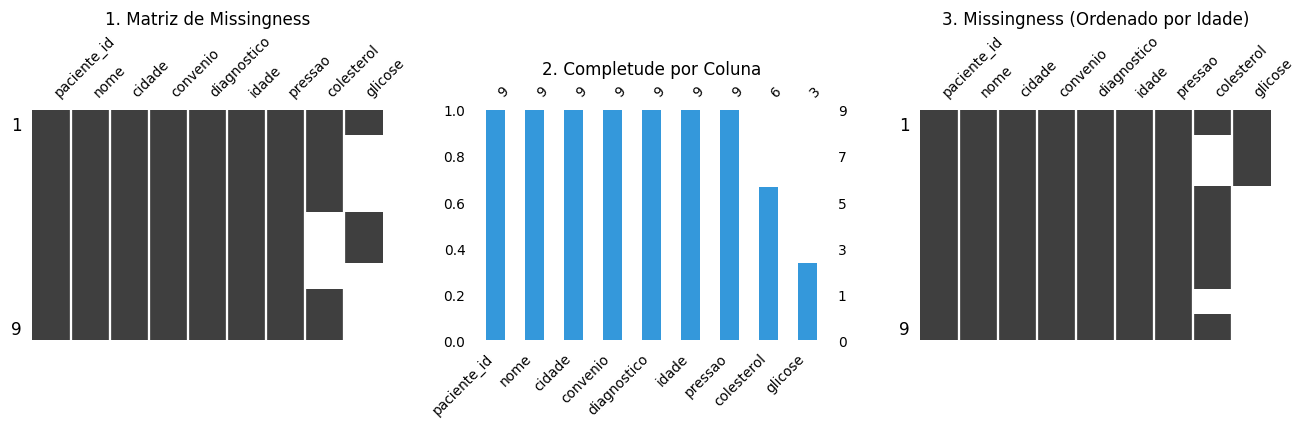

Figura salva: missingno_analise.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# 1. Matrix
msno.matrix(X_train_ausente, ax=axes[0], sparkline=False, fontsize=9)
axes[0].set_title('1. Matriz de Missingness', fontsize=11)

# 2. Bar
msno.bar(X_train_ausente, ax=axes[1], fontsize=9, color='#3498db')
axes[1].set_title('2. Completude por Coluna', fontsize=11)

# 3. Matrix Ordenada por Idade (MAR)
msno.matrix(X_train_ausente.sort_values('idade'), ax=axes[2], sparkline=False, fontsize=9)
axes[2].set_title('3. Missingness (Ordenado por Idade)', fontsize=11)

plt.tight_layout()
plt.savefig('missingno_analise.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva: missingno_analise.png")

---
## Passo 6 — Comparação de Estratégias de Imputação (Apenas na Base de Treino)

Ao imputar, as estatísticas (média, vizinhos, regressões do MICE) devem ser extraídas **somente do X_train** (`fit` no X_train e `transform` no X_train e no X_test).
Aqui avaliamos as estratégias usando simulação no próprio conjunto de treino.

In [13]:
cols_imp = ['idade', 'pressao', 'colesterol', 'glicose']
X_train_num = X_train[cols_imp].copy()

col_alvo  = 'pressao'
idx_alvo  = cols_imp.index(col_alvo)
vals_reais = X_train_num[col_alvo].values.copy()

# Introduz 30% de ausências na base de treino
np.random.seed(42)
mascara = np.random.random(len(X_train_num)) < 0.30
X_corr  = X_train_num.copy()
X_corr.loc[mascara, col_alvo] = np.nan

print(f"Linhas no X_train: {len(X_train_num)}")
print(f"Ausências inseridas em '{col_alvo}': {mascara.sum()} ({mascara.mean():.0%})")

Linhas no X_train: 9
Ausências inseridas em 'pressao': 3 (33%)


In [14]:
estrategias = {
    'Média':                   SimpleImputer(strategy='mean'),
    'Mediana':                 SimpleImputer(strategy='median'),
    'KNN (k=3)':               KNNImputer(n_neighbors=3),
    'MICE (IterativeImputer)': IterativeImputer(max_iter=20, random_state=42),
}

resultados = {}
scaler = StandardScaler()
for nome, imputador in estrategias.items():
    # FIT E TRANSFORM NA BASE DE TREINO APENAS
    if 'KNN' in nome:
        X_scaled = scaler.fit_transform(X_corr)
        X_imp_scaled = imputador.fit_transform(X_scaled)
        X_imp = scaler.inverse_transform(X_imp_scaled)
    else:
        X_imp = imputador.fit_transform(X_corr)
    rmse = np.sqrt(mean_squared_error(vals_reais[mascara], X_imp[mascara, idx_alvo]))
    resultados[nome] = rmse
    print(f"{nome:<28} RMSE = {rmse:.2f} mmHg")

Média                        RMSE = 17.23 mmHg
Mediana                      RMSE = 17.04 mmHg
KNN (k=3)                    RMSE = 5.74 mmHg
MICE (IterativeImputer)      RMSE = 4.42 mmHg


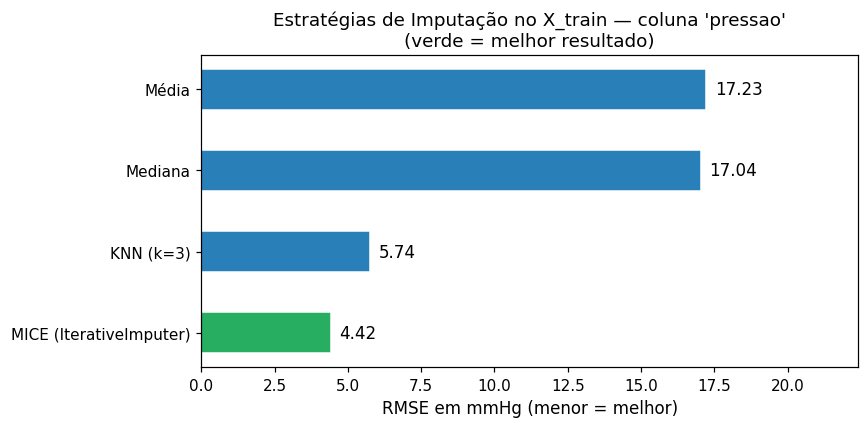

Figura salva: comparacao_imputacao.png


In [15]:
fig, ax = plt.subplots(figsize=(8, 4))

melhor = min(resultados.values())
cores  = ['#27ae60' if v == melhor else '#2980b9' for v in resultados.values()]

barras = ax.barh(list(resultados.keys()), list(resultados.values()),
                 color=cores, edgecolor='white', height=0.5)
for barra, val in zip(barras, resultados.values()):
    ax.text(val + 0.3, barra.get_y() + barra.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=11)

ax.set_xlabel('RMSE em mmHg (menor = melhor)', fontsize=11)
ax.set_title(f"Estratégias de Imputação no X_train — coluna '{col_alvo}'\n(verde = melhor resultado)",
             fontsize=12)
ax.set_xlim(0, max(resultados.values()) * 1.3)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('comparacao_imputacao.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva: comparacao_imputacao.png")

---
## Resumo do Pipeline

```
Dataset Sujo (Centralizado na Geração)
    │
    ├─ Passo 2: SHA-256 hashing → remove duplicatas exatas
    │
    ├─ Passo 3: MinHash + LSH → remove near-duplicates
    │
    ├─ Passo 4: Verificação de leakage → sempre deduplicar antes do split
    │           (Gerando X_train e X_test)
    │
    ├─ Passo 5: missingno no X_train → diagnóstico visual
    │
    └─ Passo 6: Imputação no X_train → escolha da estratégia
```

**IMPORTANTE:** a ordem importa.  
Deduplicar globalmente → split (evita leakage) → explorar ausentes no treino → treinar imputador no treino → transformar treino e teste.

---
**Referência principal:**  
Albelali & Ahmed (2025). *Hidden Leaks in Time Series Forecasting*. arXiv preprint.